In [1]:
# Living Game — Mini-Reservoir EM + Memory (k·m coupling) + Periodic Domain Flips
# Sparse encode/decode on selected cells · Fixed-Immigrant Refill · Student-t Mutations
# Encoder/Decoder biases (bE, bD) with independent init sigmas
# -----------------------------------------------------------------------------------
# Dynamics:
#   f(x)    = 1.3 * tanh(x) - 0.3 * x
#   ds/dt   = f(W @ s + k * m + b)          (elementwise k*m)
#   dm/dt   = alpha * (s - m)               (slow memory that tracks s)
# Encoding is ADDITIVE at selected cells: s[:, sel_idx] += λ * (E @ x + bE)
# Decoding with bias: y = R @ s_sel + bD
# No clipping inside the integrator; overflow/nonfinite ⇒ agent death.
#
# Extinction events (simple & deterministic):
#   • Every flip_period_s seconds, flip a global sign σ ∈ {+1,-1}
#   • Apply only to:
#       (1) life/fitness rewards on food/poison collisions: reward_effective = σ * base_reward
#       (2) the meta reward scalar input: reward_meta = σ * (one-step-delayed interaction signal)
#   • Ray sensors (distances) remain unchanged.
#   • No warmup; first flip exactly at t = flip_period_s; initial regime set by flip_initial.
# -----------------------------------------------------------------------------------

import math
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np

try:
    import pygame
    _PG = True
except ModuleNotFoundError:
    pygame = None
    _PG = False


# === Hyperparameters / Config ===
HYPERPARAMS = dict(
    # World / timing
    width=1400,
    height=900,
    dt=1/30.0,
    speed_px_s=55.0,

    # Sensors (normalized distance 0..1, 1.0 = no hit)
    n_rays=3,                 # I = 2*n_rays + 1 (reward)
    fov_deg=120.0,
    ray_length=70.0,

    # Agents
    n_target_agents=80,
    baseline_birth=20.0,
    agent_radius=5.0,
    max_life=40.0,

    # Food (green)
    food_radius=3.5,
    food_reward=+5.0,         # base reward (will be signed by domain sign)
    food_spawn_prob=0.7,
    food_max=80,

    # Poison (red)
    poison_radius=3.5,
    poison_reward=-5.0,       # base reward (will be signed by domain sign)
    poison_spawn_prob=0.7,
    poison_max=100,

    # Costs (life drain per second)
    consumption_base=0.2,
    consumption_speed_coeff=0.1,

    # Looping penalty (EMA on steer)
    ema_coeff=0.98,           # ema = alpha*ema + (1-alpha)*steer
    looping_penalty=6.0,      # per-second drain scaled by |ema_steer|

    # === Reservoir (per agent) ===
    res_N=4,                  # reservoir size
    res_T=3,                  # microsteps per world tick
    res_dt=0.3,               # microstep size
    res_abs_max=10.0,
    res_lambda_write=0.15,    # additive write gain for encoding

    # Memory dynamics
    mem_alpha=0.003,           # alpha in dm/dt = alpha * (s - m)

    # Sparse encode/decode
    mod_every=1,              # use every N%mod_every cells (N_sel = floor(N/mod_every))
    enc_clip=2.0,             # clip(E@x + bE) before adding into reservoir
    dec_gain_steer=1.0,
    dec_gain_speed=2.0,

    # Genome init (encoder/readout, reservoir weights/bias, initial states, memory & coupling)
    e_init_sigma=0.8,         # encoder matrix E
    be_init_sigma=0.0,        # encoder bias bE
    r_init_sigma=0.8,         # readout matrix R
    bd_init_sigma=0.0,        # readout bias bD
    w_init_sigma=0.25,        # W init scale
    b_init_sigma=0.2,         # reservoir bias b init scale
    s0_init_sigma=0.8,        # initial state genome prior (s0)
    m0_init_sigma=0.8,        # initial memory genome prior (m0)
    k_init_sigma=0.2,         # per-neuron coupling to memory

    # Refill trigger & composition
    refill_frac=0.4,          # trigger when alive <= refill_frac * n_target_agents
    elite_fraction=0.6,       # parents sampled from top fraction by FITNESS RATE
    immigrants_per_refill=0,  # FIXED immigrants per refill (if available in bank)

    # GA ops
    crossover_prob=0.07,

    # Fat-tail mutation (Student-t)
    mutation_prob=0.2,
    mutation_sigma_base=0.05,
    mutation_t_df=2.0,

    # Elite bank
    bank_max=512,
    bank_decay_prob=0.0,
    bank_add_every=2,

    # Meta-learning input switch
    meta_learning_enabled=True,

    # Fitness rate parameters
    fitness_rate_exponent=0.5,
    fitness_rate_epsilon=3,

    # === Extinction events (domain flips) ===
    flip_enabled=False,          # enable periodic NORMAL<->INVERTED flips
    flip_period_s=30.0,         # period (seconds) between flips, deterministic
    flip_initial="normal",      # "normal" or "inverted"
    log_every_s=1.0,            # cadence for logging mean/top5% fitness vs time
)


# --------------------------- Config dataclass ---------------------------
@dataclass
class Cfg:
    # World / timing
    width: int
    height: int
    dt: float
    speed_px_s: float

    # Sensors
    n_rays: int
    fov_deg: float
    ray_length: float

    # Agents
    n_target_agents: int
    baseline_birth: float
    agent_radius: float
    max_life: float

    # Food
    food_radius: float
    food_reward: float
    food_spawn_prob: float
    food_max: int

    # Poison
    poison_radius: float
    poison_reward: float
    poison_spawn_prob: float
    poison_max: int

    # Costs
    consumption_base: float
    consumption_speed_coeff: float

    # Looping penalty (EMA)
    ema_coeff: float
    looping_penalty: float

    # Reservoir
    res_N: int
    res_T: int
    res_dt: float
    res_abs_max: float
    res_lambda_write: float

    # Memory dynamics
    mem_alpha: float

    # Sparse encode/decode
    mod_every: int
    enc_clip: float
    dec_gain_steer: float
    dec_gain_speed: float

    # Genome init
    e_init_sigma: float
    be_init_sigma: float
    r_init_sigma: float
    bd_init_sigma: float
    w_init_sigma: float
    b_init_sigma: float
    s0_init_sigma: float
    m0_init_sigma: float
    k_init_sigma: float

    # Refill trigger & composition
    refill_frac: float
    elite_fraction: float
    immigrants_per_refill: int

    # GA ops
    crossover_prob: float
    mutation_prob: float
    mutation_sigma_base: float
    mutation_t_df: float

    # Bank
    bank_max: int
    bank_decay_prob: float
    bank_add_every: int

    # Meta-learning
    meta_learning_enabled: bool

    # Fitness rate
    fitness_rate_exponent: float
    fitness_rate_epsilon: float

    # Extinction flips
    flip_enabled: bool
    flip_period_s: float
    flip_initial: str
    log_every_s: float

    # Derived
    input_dim: int = 0  # I = 2*n_rays + 1
    output_dim: int = 2 # O = 2 (steer, speed)
    sel_idx: Optional[np.ndarray] = None
    N_sel: int = 0
    refill_threshold: int = 0

    def __post_init__(self):
        # Inputs: food rays + poison rays + reward scalar
        self.input_dim = 2 * self.n_rays + 1
        assert self.output_dim == 2

        assert self.mod_every >= 1
        self.sel_idx = np.arange(0, self.res_N, self.mod_every, dtype=np.int32)
        self.N_sel = int(self.sel_idx.size)
        assert self.N_sel >= 1, "mod_every too large; no selected cells."

        assert 0.0 < self.refill_frac <= 1.0
        assert 0.0 <= self.elite_fraction <= 1.0
        assert self.immigrants_per_refill >= 0

        assert self.flip_initial in ("normal", "inverted")
        assert self.flip_period_s > 0.0
        assert self.log_every_s > 0.0

        self.refill_threshold = int(math.floor(self.refill_frac * self.n_target_agents))


# --------------------------- Utility functions ---------------------------
def wrap_xy(xy: np.ndarray, W: float, H: float) -> None:
    xy[:, 0] %= W
    xy[:, 1] %= H


def torus_delta(A: np.ndarray, B: np.ndarray, W: float, H: float) -> np.ndarray:
    d = B[None, :, :] - A[:, None, :]
    d[..., 0] = (d[..., 0] + W/2.0) % W - W/2.0
    d[..., 1] = (d[..., 1] + H/2.0) % H - H/2.0
    return d


def pairwise_dist_torus(A: np.ndarray, B: np.ndarray, W: float, H: float) -> np.ndarray:
    d = torus_delta(A, B, W, H)
    return np.sqrt(np.sum(d * d, axis=-1))


def top_percentile_mean(values: np.ndarray, pct: float = 0.05) -> float:
    n = values.size
    if n == 0 or not np.isfinite(values).any():
        return float('nan')
    k = max(1, int(math.ceil(pct * n)))
    part = np.partition(values, n - k)
    top_k = part[n - k:]
    return float(np.mean(top_k))


# --------------------------- GA Helpers ---------------------------
def crossover_mutate(rng: np.random.Generator,
                     A_param: np.ndarray,
                     B_param: np.ndarray,
                     crossover_prob: float,
                     mut_prob: float,
                     sigma_base: float,
                     t_df: float) -> np.ndarray:
    """
    Elementwise crossover between A_param and B_param with Bernoulli mask,
    then elementwise Student-t mutation scaled by |param|+1e-3 magnitude.
    Shapes of A_param and B_param must match.
    """
    mask = (rng.random(A_param.shape) < crossover_prob)
    child = np.where(mask, A_param, B_param).astype(np.float32)

    if mut_prob > 0.0 and sigma_base > 0.0:
        m_mask = (rng.random(child.shape) < mut_prob)
        if m_mask.any():
            t_noise = rng.standard_t(df=t_df, size=int(m_mask.sum())).astype(np.float32)
            eps = 1e-3
            mag = np.abs(child[m_mask]) + eps
            child[m_mask] += (sigma_base * mag) * t_noise
    return child


# --------------------------- Reservoir + Memory dynamics ---------------------------
def reservoir_activation(z: np.ndarray) -> np.ndarray:
    # f(x) = 1.3 * tanh(x) - 0.3 * x
    return (1.3 * np.tanh(z) - 0.3 * z).astype(np.float32)


def reservoir_mem_integrate_rk2(s: np.ndarray,
                                m: np.ndarray,
                                W: np.ndarray,
                                b: np.ndarray,
                                k: np.ndarray,
                                alpha: float,
                                dt: float,
                                T: int,
                                abs_max: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Integrate coupled (s, m):
        ds/dt = f(W@s + k*m + b)
        dm/dt = alpha * (s - m)
    with RK2 (midpoint), per-agent.
      s: (A, N), m: (A, N), W: (A, N, N), b: (A, N), k: (A, N)
    Returns: (s_new, m_new, bad_agents_mask)
    """
    A, _ = s.shape
    bad = np.zeros(A, dtype=bool)

    for _ in range(T):
        # Stage 1
        z1 = np.einsum('aij,aj->ai', W, s, optimize=True) + (k * m) + b
        f1 = reservoir_activation(z1)        # ds1/dt
        g1 = alpha * (s - m)                 # dm1/dt

        s_p = s + dt * f1
        m_p = m + dt * g1

        # Stage 2
        z2 = np.einsum('aij,aj->ai', W, s_p, optimize=True) + (k * m_p) + b
        f2 = reservoir_activation(z2)        # ds2/dt
        g2 = alpha * (s_p - m_p)             # dm2/dt

        s_new = s + 0.5 * dt * (f1 + f2)
        m_new = m + 0.5 * dt * (g1 + g2)

        # Validity checks
        nonfinite = ~(np.isfinite(s_new).all(axis=1) & np.isfinite(m_new).all(axis=1))
        overflow  = (np.max(np.abs(s_new), axis=1) > abs_max) | (np.max(np.abs(m_new), axis=1) > abs_max)
        step_bad  = nonfinite | overflow
        bad |= step_bad

        if bad.any():
            keep = ~bad
            if keep.any():
                s[keep] = s_new[keep]
                m[keep] = m_new[keep]
        else:
            s = s_new
            m = m_new

    return s, m, bad


# --------------------------- Agent helpers ---------------------------
def random_spawn(N: int, w: float, h: float, baseline_birth: float, rng: np.random.Generator):
    xy = np.empty((N, 2), np.float32)
    xy[:, 0] = rng.uniform(0, w, N)
    xy[:, 1] = rng.uniform(0, h, N)
    heading = rng.uniform(0.0, 2.0 * math.pi, N).astype(np.float32)
    speed = np.zeros(N, np.float32)
    life = np.full(N, baseline_birth, np.float32)
    age = np.zeros(N, np.float32)
    return xy, heading, speed, life, age


def spawn_near(parent_xy: np.ndarray, w: float, h: float, rng: np.random.Generator, sigma: float = 80.0):
    xy = parent_xy + rng.normal(0.0, sigma, size=(1, 2)).astype(np.float32)
    xy[:, 0] %= w
    xy[:, 1] %= h
    heading = rng.uniform(0.0, 2.0 * math.pi, 1).astype(np.float32)
    speed = np.zeros(1, np.float32)
    return xy, heading, speed


# --------------------------- World ---------------------------
class World:
    def __init__(self, cfg: Cfg):
        self.cfg = cfg
        self.rng = np.random.default_rng()  # fully random
        self.time = 0.0
        self.step_count = 0
        self.ga_log = []
        self._compute_ray_angles()

        # --- Extinction event bookkeeping ---
        self.domain_inverted = (cfg.flip_initial == "inverted")
        self._domain_sign = -1.0 if self.domain_inverted else +1.0  # σ ∈ {+1,-1}
        self._next_flip_time = cfg.flip_period_s if cfg.flip_enabled else float('inf')
        self._next_log_time = cfg.log_every_s

        # Simple in-memory logs for later plotting
        self.sim_log = dict(t=[], mean_fit=[], top5_fit=[], regime=[])

        N = cfg.res_N
        I = cfg.input_dim
        O = cfg.output_dim
        N_sel = cfg.N_sel

        # Agents (initial surge for exploration)
        A = cfg.n_target_agents * 40
        self.a_xy, self.a_dir, self.a_speed, self.a_life, self.a_age = random_spawn(
            A, cfg.width, cfg.height, cfg.baseline_birth, self.rng
        )

        # Genome per agent (reservoir core)
        self.gen_W  = self.rng.normal(0.0, cfg.w_init_sigma, size=(A, N, N)).astype(np.float32)
        self.gen_b  = self.rng.normal(0.0, cfg.b_init_sigma, size=(A, N)).astype(np.float32)
        self.gen_s0 = self.rng.normal(0.0, cfg.s0_init_sigma, size=(A, N)).astype(np.float32)

        # Memory genome & coupling
        self.gen_m0 = self.rng.normal(0.0, cfg.m0_init_sigma, size=(A, N)).astype(np.float32)
        self.gen_k  = self.rng.normal(0.0, cfg.k_init_sigma,  size=(A, N)).astype(np.float32)

        # Runtime states start from priors
        self.res_s  = self.gen_s0.copy().astype(np.float32)
        self.mem_m  = self.gen_m0.copy().astype(np.float32)

        # Sparse encoder/decoder + biases
        self.gen_E  = self.rng.normal(0.0, cfg.e_init_sigma,  size=(A, N_sel, I)).astype(np.float32)
        self.gen_bE = self.rng.normal(0.0, cfg.be_init_sigma, size=(A, N_sel)).astype(np.float32)
        self.gen_R  = self.rng.normal(0.0, cfg.r_init_sigma,  size=(A, O, N_sel)).astype(np.float32)
        self.gen_bD = self.rng.normal(0.0, cfg.bd_init_sigma, size=(A, O)).astype(np.float32)

        # Fitness and EMA-based looping penalty
        self.a_fit = np.zeros(A, np.float32)
        self.ema_steer = np.zeros(A, np.float32)

        # Reward (one-step delayed signal)
        self._reward_signal = np.zeros(A, dtype=np.float32)

        # Elite bank (snapshots of genomes)
        self.elite_bank = []  # list of dicts
        self._bank_cycle_count = 0

        # World resources
        self.f_xy = self._spawn_food(cfg.food_max // 2)
        self.p_xy = self._spawn_poison(cfg.poison_max // 2)

        # Sensor cache (rays)
        self._last_sensor = np.ones((A, 2 * cfg.n_rays), np.float32)

        regime_str = "INVERTED" if self.domain_inverted else "NORMAL"
        print(f"Initialized: A={A}, N={N}, N_sel={N_sel}, I={I}, O={O}")
        print(f"Sparse sel_idx: {cfg.sel_idx.tolist()}")
        print(f"Reservoir write: additive with lambda={cfg.res_lambda_write} | enc_clip={cfg.enc_clip}")
        print(f"Memory alpha={cfg.mem_alpha} | fitness-rate exponent={cfg.fitness_rate_exponent} epsilon={cfg.fitness_rate_epsilon}")
        print(f"Extinction events: enabled={cfg.flip_enabled} | period={cfg.flip_period_s}s | initial regime={regime_str}")

    # ---------- Sensors ----------
    def _compute_ray_angles(self):
        k = self.cfg.n_rays
        if k == 1:
            self._ray_rel_angles = np.array([0.0], np.float32)
        else:
            span = math.radians(self.cfg.fov_deg)
            self._ray_rel_angles = np.linspace(-span / 2.0, span / 2.0, k, dtype=np.float32)

    def _spawn_food(self, n: int) -> np.ndarray:
        n = int(n)
        if n <= 0:
            return np.empty((0, 2), np.float32)
        xy = np.empty((n, 2), np.float32)
        xy[:, 0] = self.rng.uniform(0, self.cfg.width, n)
        xy[:, 1] = self.rng.uniform(0, self.cfg.height, n)
        return xy

    def _spawn_poison(self, n: int) -> np.ndarray:
        n = int(n)
        if n <= 0:
            return np.empty((0, 2), np.float32)
        xy = np.empty((n, 2), np.float32)
        xy[:, 0] = self.rng.uniform(0, self.cfg.width, n)
        xy[:, 1] = self.rng.uniform(0, self.cfg.height, n)
        return xy

    def _sense(self) -> np.ndarray:
        cfg = self.cfg
        A = len(self.a_xy)
        k = cfg.n_rays
        X = np.ones((A, 2 * k), np.float32)  # [food rays, poison rays]
        if A == 0:
            return X

        W, H, rng_len = cfg.width, cfg.height, cfg.ray_length
        targets_sets = [(self.f_xy, 0), (self.p_xy, k)]

        for targets, out_off in targets_sets:
            T = len(targets)
            if T == 0:
                continue

            delta = torus_delta(self.a_xy, targets, W, H)
            dist = np.sqrt(np.sum(delta * delta, axis=-1))
            angles_abs = np.arctan2(delta[..., 1], delta[..., 0])

            if k == 1:
                half_beam = math.radians(cfg.fov_deg) / 2.0
                step = None
            else:
                step = math.radians(cfg.fov_deg) / (k - 1)

            for j, rel in enumerate(self._ray_rel_angles):
                dir_j = (self.a_dir + rel) % (2.0 * math.pi)
                dtheta = np.abs(np.angle(np.exp(1j * (angles_abs - dir_j[:, None]))))
                in_beam = (dtheta < half_beam) if k == 1 else (dtheta < (step / 2.0))
                mask = in_beam & (dist <= rng_len)
                if not mask.any():
                    continue

                nearest = np.where(mask, dist, np.inf)
                dmin = nearest.min(axis=1)
                norm = dmin / rng_len
                inf_mask = np.isinf(norm)
                if inf_mask.any():
                    norm[inf_mask] = 1.0
                X[:, out_off + j] = norm.astype(np.float32)

        return X

    def _build_input_vector(self, X: np.ndarray) -> np.ndarray:
        """x = [f', p', reward], shape (A, I).  reward := σ * (one-step delayed interaction)."""
        cfg = self.cfg
        k = cfg.n_rays
        X_food = X[:, :k]
        X_poison = X[:, k:2*k]

        # distances (0..1) → signed proximity (-1..+1)
        fprime = 1.0 - 2.0 * X_food
        pprime = 1.0 - 2.0 * X_poison

        # Meta reward channel (if enabled): multiply by domain sign σ
        if cfg.meta_learning_enabled:
            reward = (self._domain_sign * self._reward_signal)[:, None].astype(np.float32)
        else:
            reward = np.zeros_like(self._reward_signal[:, None], dtype=np.float32)

        x = np.concatenate([fprime, pprime, reward], axis=1)
        return x

    def _maybe_flip_domain(self):
        """Deterministic NORMAL↔INVERTED flip at fixed period."""
        if self.cfg.flip_enabled and (self.time >= self._next_flip_time):
            self.domain_inverted = not self.domain_inverted
            self._domain_sign = -1.0 if self.domain_inverted else +1.0
            self._next_flip_time += self.cfg.flip_period_s
            print(f"[Flip] t={self.time:.2f}s → regime={'INVERTED' if self.domain_inverted else 'NORMAL'}")

    def _maybe_log(self):
        """Log mean and top5% fitness vs time at a fixed cadence."""
        if self.time >= self._next_log_time:
            mean_fit = float(np.mean(self.a_fit)) if len(self.a_fit) else float('nan')
            top5_fit = top_percentile_mean(self.a_fit, 0.05) if len(self.a_fit) else float('nan')
            self.sim_log['t'].append(float(self.time))
            self.sim_log['mean_fit'].append(mean_fit)
            self.sim_log['top5_fit'].append(top5_fit)
            self.sim_log['regime'].append(1 if self.domain_inverted else 0)
            self._next_log_time += self.cfg.log_every_s

    # ---------- One world step ----------
    def step(self):
        cfg = self.cfg
        A = len(self.a_xy)

        # Periodic domain flip (before sensing/acting so HUD aligns)
        self._maybe_flip_domain()

        X = self._sense()
        self._last_sensor = X

        if A == 0:
            self.time += cfg.dt
            self.step_count += 1
            if len(self.a_xy) <= cfg.refill_threshold:
                self._refill_population()
            self._maybe_log()
            return

        # ----- Encode (sparse) → ADD to reservoir at selected indices -----
        x = self._build_input_vector(X)  # (A, I)
        u_sel = (np.einsum('ani,ai->an', self.gen_E, x, optimize=True) + self.gen_bE)  # (A, N_sel)
        if cfg.enc_clip is not None and cfg.enc_clip > 0:
            np.clip(u_sel, -cfg.enc_clip, cfg.enc_clip, out=u_sel)

        lam = cfg.res_lambda_write
        self.res_s[:, cfg.sel_idx] += (lam * u_sel)

        # ----- Integrate (s, m) with RK2 -----
        self.res_s, self.mem_m, bad = reservoir_mem_integrate_rk2(
            self.res_s, self.mem_m, self.gen_W, self.gen_b, self.gen_k,
            cfg.mem_alpha, cfg.res_dt, cfg.res_T, cfg.res_abs_max
        )
        if bad.any():
            self.a_life[bad] = -1.0  # instant death on overflow/NaN

        # ----- Decode from selected indices to actions -----
        s_sel = self.res_s[:, cfg.sel_idx]  # (A, N_sel)
        y = (np.einsum('aon,an->ao', self.gen_R, s_sel, optimize=True) + self.gen_bD)  # (A, 2)
        steer_raw = y[:, 0] * cfg.dec_gain_steer
        speed_raw = y[:, 1] * cfg.dec_gain_speed

        steer = np.clip(steer_raw, -1.0, 1.0).astype(np.float32)
        speed_cmd = np.clip(0.5 + 0.5 * speed_raw, 0.0, 1.0).astype(np.float32)

        # ----- Kinematics -----
        self.a_dir = (self.a_dir + steer * (math.pi / 4.0)) % (2.0 * math.pi)
        self.a_speed = speed_cmd
        dx = self.a_speed * np.cos(self.a_dir) * cfg.speed_px_s * cfg.dt
        dy = self.a_speed * np.sin(self.a_dir) * cfg.speed_px_s * cfg.dt
        self.a_xy[:, 0] += dx
        self.a_xy[:, 1] += dy
        wrap_xy(self.a_xy, cfg.width, cfg.height)

        # ----- EMA looping penalty -----
        alpha = cfg.ema_coeff
        self.ema_steer = alpha * self.ema_steer + (1.0 - alpha) * steer
        loop_penalty_rate = cfg.looping_penalty * np.abs(self.ema_steer)

        # ----- Life consumption & continuous penalties → fitness -----
        speed_cost = cfg.consumption_speed_coeff * self.a_speed
        baseline = cfg.consumption_base
        total_cost = baseline + speed_cost + loop_penalty_rate

        self.a_life -= cfg.dt * total_cost
        self.a_fit  -= cfg.dt * (speed_cost + loop_penalty_rate) * 0.1  # small continuous penalty in fitness

        # ----- Collisions (food/poison) → life & fitness (SIGNED by domain) -----
        ate_any = np.zeros(A, dtype=bool)
        if len(self.f_xy):
            dist_af = pairwise_dist_torus(self.a_xy, self.f_xy, cfg.width, cfg.height)
            hit_f = dist_af < (cfg.agent_radius + cfg.food_radius)
            a_idx_f, f_idx = np.where(hit_f)
            if len(a_idx_f):
                eaten_counts = np.bincount(a_idx_f, minlength=A).astype(np.float32)
                eff_food = self._domain_sign * cfg.food_reward
                self.a_life[:len(eaten_counts)] += eaten_counts * eff_food
                self.a_fit[:len(eaten_counts)]  += eaten_counts * eff_food
                ate_any[:len(eaten_counts)] = eaten_counts > 0

                keep = np.ones(len(self.f_xy), dtype=bool)
                keep[f_idx] = False
                self.f_xy = self.f_xy[keep]

        poisoned_any = np.zeros(A, dtype=bool)
        if len(self.p_xy):
            dist_ap = pairwise_dist_torus(self.a_xy, self.p_xy, cfg.width, cfg.height)
            hit_p = dist_ap < (cfg.agent_radius + cfg.poison_radius)
            a_idx_p, p_idx = np.where(hit_p)
            if len(a_idx_p):
                poisoned_counts = np.bincount(a_idx_p, minlength=A).astype(np.float32)
                eff_poison = self._domain_sign * cfg.poison_reward
                self.a_life[:len(poisoned_counts)] += poisoned_counts * eff_poison
                self.a_fit[:len(poisoned_counts)]  += poisoned_counts * eff_poison
                poisoned_any[:len(poisoned_counts)] = poisoned_counts > 0

                keep_p = np.ones(len(self.p_xy), dtype=bool)
                keep_p[p_idx] = False
                self.p_xy = self.p_xy[keep_p]

        # One-step delayed reward for meta input (sign applied in _build_input_vector)
        reward = ate_any.astype(np.int8) - poisoned_any.astype(np.int8)
        reward = np.clip(reward, -1, 1).astype(np.float32)
        self._reward_signal = reward

        # Cap life & spawn resources
        self.a_life = np.minimum(self.a_life, cfg.max_life).astype(np.float32)

        if (len(self.f_xy) < cfg.food_max) and (self.rng.random() < cfg.food_spawn_prob):
            self.f_xy = np.vstack([self.f_xy, self._spawn_food(1)]) if len(self.f_xy) else self._spawn_food(1)

        if (len(self.p_xy) < cfg.poison_max) and (self.rng.random() < cfg.poison_spawn_prob):
            self.p_xy = np.vstack([self.p_xy, self._spawn_poison(1)]) if len(self.p_xy) else self._spawn_poison(1)

        # Cull dead
        alive_mask = self.a_life > 0.0
        if not alive_mask.all():
            self._prune_dead(alive_mask)

        # Advance time & age
        self.time += cfg.dt
        self.step_count += 1
        self.a_age += cfg.dt

        # Periodic logging (after step)
        self._maybe_log()

        # Refill trigger
        if len(self.a_xy) <= cfg.refill_threshold:
            self._refill_population()

    def _prune_dead(self, alive_mask: np.ndarray):
        self.a_xy   = self.a_xy[alive_mask]
        self.a_dir  = self.a_dir[alive_mask]
        self.a_speed= self.a_speed[alive_mask]
        self.a_life = self.a_life[alive_mask]
        self.a_fit  = self.a_fit[alive_mask]
        self.a_age  = self.a_age[alive_mask]
        self.ema_steer = self.ema_steer[alive_mask]

        self.res_s  = self.res_s[alive_mask]
        self.mem_m  = self.mem_m[alive_mask]

        self.gen_W  = self.gen_W[alive_mask]
        self.gen_b  = self.gen_b[alive_mask]
        self.gen_s0 = self.gen_s0[alive_mask]

        self.gen_m0 = self.gen_m0[alive_mask]
        self.gen_k  = self.gen_k[alive_mask]

        self.gen_E  = self.gen_E[alive_mask]
        self.gen_bE = self.gen_bE[alive_mask]
        self.gen_R  = self.gen_R[alive_mask]
        self.gen_bD = self.gen_bD[alive_mask]

        if len(self._last_sensor):
            self._last_sensor = self._last_sensor[alive_mask]
        if len(self._reward_signal):
            self._reward_signal = self._reward_signal[alive_mask]

    # ---------- Selection helpers ----------
    def _fitness_rate_array(self) -> np.ndarray:
        # fitness_rate = a_fit / (age**exponent + epsilon)
        exp = self.cfg.fitness_rate_exponent
        eps = self.cfg.fitness_rate_epsilon
        denom = ((self.a_age + eps) ** exp)
        return self.a_fit / denom

    # ---------- GA refill ----------
    def _refill_population(self):
        cfg = self.cfg
        A = len(self.a_xy)
        target = cfg.n_target_agents
        needed = max(0, target - A)

        # Elite pool by FITNESS RATE
        if A > 0 and cfg.elite_fraction > 0.0:
            fr = self._fitness_rate_array()
            order = np.argsort(-fr)  # descending by rate
            elite_size = max(1, int(math.ceil(cfg.elite_fraction * A)))
            elite_idx = order[:elite_size]
        else:
            elite_size = 0
            elite_idx = np.array([], dtype=int)

        # Snapshot best-by-rate into bank
        self._bank_cycle_count += 1
        if A > 0 and (self._bank_cycle_count % cfg.bank_add_every == 0):
            fr = self._fitness_rate_array()
            best_i = int(np.argmax(fr))
            entry = {
                "W":  self.gen_W[best_i].copy(),
                "b":  self.gen_b[best_i].copy(),
                "s0": self.gen_s0[best_i].copy(),
                "m0": self.gen_m0[best_i].copy(),
                "k":  self.gen_k[best_i].copy(),
                "E":  self.gen_E[best_i].copy(),
                "bE": self.gen_bE[best_i].copy(),
                "R":  self.gen_R[best_i].copy(),
                "bD": self.gen_bD[best_i].copy(),
                "fit": float(self.a_fit[best_i]),
                "age": float(self.a_age[best_i]),
                "rate": float(fr[best_i]),
                "step": int(self.step_count)
            }
            self.elite_bank.append(entry)
            if len(self.elite_bank) > cfg.bank_max:
                overflow = len(self.elite_bank) - cfg.bank_max
                if overflow > 0:
                    self.elite_bank = self.elite_bank[overflow:]

        # Bank decay (unchanged)
        if len(self.elite_bank) and cfg.bank_decay_prob > 0.0:
            keep_list = []
            for e in self.elite_bank:
                if self.rng.random() >= cfg.bank_decay_prob:
                    keep_list.append(e)
            self.elite_bank = keep_list

        # Logging (before)
        mean_life_before = float(np.mean(self.a_life)) if A > 0 else float('nan')
        mean_fit_before  = float(np.mean(self.a_fit))  if A > 0 else float('nan')
        top5_before      = top_percentile_mean(self.a_fit, 0.05) if A > 0 else float('nan')

        if needed == 0:
            bank_size = len(self.elite_bank)
            log = {
                't': float(self.time), 'step': int(self.step_count),
                'alive_before': int(A), 'needed': 0,
                'immigrants': 0, 'children': 0, 'alive_after': int(A),
                'mean_life_before': mean_life_before,
                'mean_fit_before':  mean_fit_before,
                'top5_fit_before':  top5_before,
                'mean_life_after':  mean_life_before,
                'mean_fit_after':   mean_fit_before,
                'top5_fit_after':   top5_before,
                'elite_size': int(elite_size),
                'bank_size': int(bank_size)
            }
            self.ga_log.append(log)
            print(f"[Refill] t={self.time:.2f}s step={self.step_count} | alive={A}/{target} (no fill) | "
                  f"mean_fit={mean_fit_before:.2f} | top5%={top5_before:.2f} | bank={bank_size}")
            return

        # ---- FIXED immigrants + ONLY children for remainder ----
        immigrants = min(needed, len(self.elite_bank), cfg.immigrants_per_refill)
        children = needed - immigrants

        N, I, O, N_sel = cfg.res_N, cfg.input_dim, cfg.output_dim, cfg.N_sel

        new_xy = []; new_dir = []; new_speed = []; new_life = []; new_age = []
        new_s  = []; new_m = []
        new_W = []; new_b = []; new_s0 = []; new_m0 = []; new_k = []
        new_E  = []; new_bE = []; new_R = []; new_bD = []
        new_fit = []; new_reward_signal = []; new_ema_steer = []

        # Immigrants: exact copies from bank
        if immigrants > 0:
            idxs = self.rng.choice(len(self.elite_bank), size=immigrants, replace=False)
            xy_i, dir_i, speed_i, life_i, age_i = random_spawn(immigrants, cfg.width, cfg.height, cfg.baseline_birth, self.rng)

            W_i  = np.empty((immigrants, N, N), dtype=np.float32)
            b_i  = np.empty((immigrants, N), dtype=np.float32)
            s0_i = np.empty((immigrants, N), dtype=np.float32)
            m0_i = np.empty((immigrants, N), dtype=np.float32)
            k_i  = np.empty((immigrants, N), dtype=np.float32)
            E_i  = np.empty((immigrants, N_sel, I), dtype=np.float32)
            bE_i = np.empty((immigrants, N_sel), dtype=np.float32)
            R_i  = np.empty((immigrants, O, N_sel), dtype=np.float32)
            bD_i = np.empty((immigrants, O), dtype=np.float32)

            for j, bank_idx in enumerate(idxs):
                be = self.elite_bank[bank_idx]
                W_i[j]  = be["W"]
                b_i[j]  = be["b"]
                s0_i[j] = be["s0"]
                m0_i[j] = be["m0"]
                k_i[j]  = be["k"]
                E_i[j]  = be["E"]
                bE_i[j] = be["bE"]
                R_i[j]  = be["R"]
                bD_i[j] = be["bD"]

            s_i = s0_i.copy()
            m_i = m0_i.copy()

            new_xy.append(xy_i); new_dir.append(dir_i); new_speed.append(speed_i); new_life.append(life_i); new_age.append(age_i)
            new_s.append(s_i); new_m.append(m_i)
            new_W.append(W_i); new_b.append(b_i); new_s0.append(s0_i); new_m0.append(m0_i); new_k.append(k_i)
            new_E.append(E_i); new_bE.append(bE_i); new_R.append(R_i); new_bD.append(bD_i)
            new_fit.append(np.zeros(immigrants, np.float32))
            new_reward_signal.append(np.zeros(immigrants, np.float32))
            new_ema_steer.append(np.zeros(immigrants, np.float32))

        # Children from fitness-elite
        if children > 0 and elite_size > 0:
            for _ in range(children):
                pa = int(elite_idx[self.rng.integers(0, elite_size)])
                pb = int(elite_idx[self.rng.integers(0, elite_size)])

                xy_c, dir_c, speed_c = spawn_near(self.a_xy[pa:pa+1], cfg.width, cfg.height, self.rng)
                life_c = np.array([cfg.baseline_birth], dtype=np.float32)
                age_c  = np.array([0.0], dtype=np.float32)

                W_c  = crossover_mutate(self.rng, self.gen_W[pa],  self.gen_W[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                b_c  = crossover_mutate(self.rng, self.gen_b[pa],  self.gen_b[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                s0_c = crossover_mutate(self.rng, self.gen_s0[pa], self.gen_s0[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                m0_c = crossover_mutate(self.rng, self.gen_m0[pa], self.gen_m0[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                k_c  = crossover_mutate(self.rng, self.gen_k[pa],  self.gen_k[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                E_c  = crossover_mutate(self.rng, self.gen_E[pa],  self.gen_E[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                bE_c = crossover_mutate(self.rng, self.gen_bE[pa], self.gen_bE[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                R_c  = crossover_mutate(self.rng, self.gen_R[pa],  self.gen_R[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)
                bD_c = crossover_mutate(self.rng, self.gen_bD[pa], self.gen_bD[pb],
                                        cfg.crossover_prob, cfg.mutation_prob,
                                        cfg.mutation_sigma_base, cfg.mutation_t_df)

                s_c = s0_c[None, :].copy()
                m_c = m0_c[None, :].copy()

                new_xy.append(xy_c); new_dir.append(dir_c); new_speed.append(speed_c); new_life.append(life_c); new_age.append(age_c)
                new_s.append(s_c); new_m.append(m_c)
                new_W.append(W_c[None, ...]); new_b.append(b_c[None, ...]); new_s0.append(s0_c[None, ...]); new_m0.append(m0_c[None, ...]); new_k.append(k_c[None, ...])
                new_E.append(E_c[None, ...]); new_bE.append(bE_c[None, ...]); new_R.append(R_c[None, ...]); new_bD.append(bD_c[None, ...])
                new_fit.append(np.zeros(1, np.float32))
                new_reward_signal.append(np.zeros(1, np.float32))
                new_ema_steer.append(np.zeros(1, np.float32))

        # Concatenate
        if len(new_xy):
            self.a_xy    = np.vstack([self.a_xy] + new_xy) if len(self.a_xy) else np.vstack(new_xy)
            self.a_dir   = np.concatenate([self.a_dir] + new_dir) if len(self.a_dir) else np.concatenate(new_dir)
            self.a_speed = np.concatenate([self.a_speed] + new_speed) if len(self.a_speed) else np.concatenate(new_speed)
            self.a_life  = np.concatenate([self.a_life] + new_life) if len(self.a_life) else np.concatenate(new_life)
            self.a_age   = np.concatenate([self.a_age] + new_age) if len(self.a_age) else np.concatenate(new_age)

            self.res_s = np.vstack([self.res_s] + new_s) if len(self.res_s) else np.vstack(new_s)
            self.mem_m = np.vstack([self.mem_m] + new_m) if len(self.mem_m) else np.vstack(new_m)

            self.gen_W  = np.vstack([self.gen_W]  + new_W)  if len(self.gen_W)  else np.vstack(new_W)
            self.gen_b  = np.vstack([self.gen_b]  + new_b)  if len(self.gen_b)  else np.vstack(new_b)
            self.gen_s0 = np.vstack([self.gen_s0] + new_s0) if len(self.gen_s0) else np.vstack(new_s0)
            self.gen_m0 = np.vstack([self.gen_m0] + new_m0) if len(self.gen_m0) else np.vstack(new_m0)
            self.gen_k  = np.vstack([self.gen_k]  + new_k)  if len(self.gen_k)  else np.vstack(new_k)

            self.gen_E  = np.vstack([self.gen_E]  + new_E)  if len(self.gen_E)  else np.vstack(new_E)
            self.gen_bE = np.vstack([self.gen_bE] + new_bE) if len(self.gen_bE) else np.vstack(new_bE)
            self.gen_R  = np.vstack([self.gen_R]  + new_R)  if len(self.gen_R)  else np.vstack(new_R)
            self.gen_bD = np.vstack([self.gen_bD] + new_bD) if len(self.gen_bD) else np.vstack(new_bD)

            self.a_fit = np.concatenate([self.a_fit] + new_fit) if len(self.a_fit) else np.concatenate(new_fit)
            self._reward_signal = np.concatenate([self._reward_signal] + new_reward_signal) if len(self._reward_signal) else np.concatenate(new_reward_signal)
            self.ema_steer = np.concatenate([self.ema_steer] + new_ema_steer) if len(self.ema_steer) else np.concatenate(new_ema_steer)

            if len(self._last_sensor):
                extra = np.ones((len(self.a_xy) - len(self._last_sensor), 2*self.cfg.n_rays), np.float32)
                self._last_sensor = np.vstack([self._last_sensor, extra])
            else:
                self._last_sensor = np.ones((len(self.a_xy), 2*self.cfg.n_rays), np.float32)

        A_after = len(self.a_xy)
        mean_life_after = float(np.mean(self.a_life)) if A_after > 0 else float('nan')
        mean_fit_after  = float(np.mean(self.a_fit))  if A_after > 0 else float('nan')
        top5_after      = top_percentile_mean(self.a_fit, 0.05) if A_after > 0 else float('nan')

        log = {
            't': float(self.time),
            'step': int(self.step_count),
            'alive_before': int(A),
            'needed': int(needed),
            'immigrants': int(immigrants),
            'children': int(children),
            'alive_after': int(A_after),
            'mean_life_before': mean_life_before,
            'mean_fit_before':  mean_fit_before,
            'top5_fit_before':  top5_before,
            'mean_life_after':  mean_life_after,
            'mean_fit_after':   mean_fit_after,
            'top5_fit_after':   top5_after,
            'elite_size': int(elite_size),
            'bank_size': int(len(self.elite_bank))
        }
        self.ga_log.append(log)
        print(f"[Refill] t={self.time:.2f}s step={self.step_count} | alive {A}→{A_after} "
              f"(need {needed}, imm {immigrants}, child {children}) | "
              f"mean_fit={mean_fit_after:.2f} | top5%={top5_after:.2f} | bank={len(self.elite_bank)}")

    # ---------- Drawing ----------
    def draw(self, screen):
        if not (_PG and (pygame is not None)):
            return
        cfg = self.cfg
        screen.fill((0, 0, 0))

        k = cfg.n_rays
        for i, (pos, heading) in enumerate(zip(self.a_xy, self.a_dir)):
            for j, rel_angle in enumerate(self._ray_rel_angles):
                ray_angle = heading + rel_angle
                ray_dir = np.array([math.cos(ray_angle), math.sin(ray_angle)])
                ray_end = pos + ray_dir * cfg.ray_length
                ray_end[0] = np.clip(ray_end[0], 0, cfg.width)
                ray_end[1] = np.clip(ray_end[1], 0, cfg.height)

                food_d = self._last_sensor[i, j] if i < len(self._last_sensor) else 1.0
                poison_d = self._last_sensor[i, j + k] if i < len(self._last_sensor) else 1.0

                if food_d < 0.9:
                    color = (0, 255, 0); thickness = 2
                elif poison_d < 0.9:
                    color = (255, 100, 100); thickness = 2
                else:
                    color = (60, 60, 60); thickness = 1

                pygame.draw.line(screen, color, pos.astype(int), ray_end.astype(int), thickness)

        # Food (green)
        for pos in self.f_xy:
            pygame.draw.circle(screen, (0, 180, 0), pos.astype(int), int(cfg.food_radius))

        # Poison (red)
        for pos in self.p_xy:
            pygame.draw.circle(screen, (220, 50, 50), pos.astype(int), int(cfg.poison_radius))

        # Agents
        for pos, ang in zip(self.a_xy, self.a_dir):
            pygame.draw.circle(screen, (50, 120, 255), pos.astype(int), int(cfg.agent_radius))
            end = pos + np.array([math.cos(ang), math.sin(ang)]) * cfg.agent_radius
            pygame.draw.line(screen, (255, 255, 255), pos.astype(int), end.astype(int), 2)


# --------------------------- Runner ---------------------------
def build_cfg_from_hparams(hparams: dict) -> Cfg:
    return Cfg(**hparams)


def run(cfg: Cfg, steps: int = 3000, vis: bool = True, fps: int = 60) -> World:
    world = World(cfg)
    if vis:
        if not _PG or (pygame is None):
            raise RuntimeError("Pygame not available but vis=True was requested.")

        pygame.init()
        screen = pygame.display.set_mode((cfg.width, cfg.height))
        pygame.display.set_caption("Living Game – Reservoir+Memory (Sparse Enc/Dec + Fixed Immigrants) — Extinction Events")
        clock = pygame.time.Clock()
        font = pygame.font.Font(None, 24)

        running = True
        report_every = max(1, int(0.5 / cfg.dt))  # ~ every 0.5s
        while running:
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    running = False

            world.step()
            world.draw(screen)

            if (world.step_count % report_every) == 0:
                mean_life = float(np.mean(world.a_life)) if len(world.a_life) else float('nan')
                mean_fit  = float(np.mean(world.a_fit))  if len(world.a_fit)  else float('nan')
                top5_fit  = top_percentile_mean(world.a_fit, 0.05) if len(world.a_fit) else float('nan')
                ema_bias_mean = float(np.mean(np.abs(world.ema_steer))) if len(world.ema_steer) else float('nan')
                regime = "INVERTED" if world.domain_inverted else "NORMAL"
                t_to_flip = max(0.0, world._next_flip_time - world.time)
                print(
                    f"t={world.time:6.2f}s | step={world.step_count:6d} | alive={len(world.a_xy):3d}/{cfg.n_target_agents} "
                    f"| food={len(world.f_xy):3d} | poison={len(world.p_xy):3d} "
                    f"| mean life={mean_life:.2f} | mean fit={mean_fit:.2f} | top5% fit={top5_fit:.2f} "
                    f"| |EMA(steer)|={ema_bias_mean:.2f} | bank={len(world.elite_bank)} "
                    f"| Regime={regime} | next flip in {t_to_flip:5.1f}s"
                )

            # HUD
            mean_life = float(np.mean(world.a_life)) if len(world.a_life) else float('nan')
            mean_fit  = float(np.mean(world.a_fit))  if len(world.a_fit)  else float('nan')
            top5_fit  = top_percentile_mean(world.a_fit, 0.05) if len(world.a_fit) else float('nan')
            regime = "INVERTED" if world.domain_inverted else "NORMAL"
            t_to_flip = max(0.0, world._next_flip_time - world.time)

            hud = (
                f"t={world.time:6.2f}s | alive={len(world.a_xy):3d}/{cfg.n_target_agents} "
                f"| food={len(world.f_xy):3d} | poison={len(world.p_xy):3d} "
                f"| mean fit={mean_fit:.2f} | top5% fit={top5_fit:.2f} "
                f"| Regime={regime} | next flip in {t_to_flip:5.1f}s"
            )
            screen.fill((0,0,0))
            world.draw(screen)
            surf = font.render(hud, True, (255, 255, 255))
            screen.blit(surf, (10, 10))

            pygame.display.flip()
            clock.tick(fps)
        pygame.quit()
    else:
        report_every = max(1, int(0.5 / cfg.dt))  # ~ every 0.5s
        for i in range(steps):
            world.step()
            if (i % report_every) == 0:
                mean_life = float(np.mean(world.a_life)) if len(world.a_life) else float('nan')
                mean_fit  = float(np.mean(world.a_fit))  if len(world.a_fit)  else float('nan')
                top5_fit  = top_percentile_mean(world.a_fit, 0.05) if len(world.a_fit) else float('nan')
                ema_bias_mean = float(np.mean(np.abs(world.ema_steer))) if len(world.ema_steer) else float('nan')
                regime = "INVERTED" if world.domain_inverted else "NORMAL"
                t_to_flip = max(0.0, world._next_flip_time - world.time)
                print(
                    f"t={world.time:6.2f}s | step={world.step_count:6d} | alive={len(world.a_xy):3d}/{cfg.n_target_agents} "
                    f"| food={len(world.f_xy):3d} | poison={len(world.p_xy):3d} "
                    f"| mean life={mean_life:.2f} | mean fit={mean_fit:.2f} | top5% fit={top5_fit:.2f} "
                    f"| |EMA(steer)|={ema_bias_mean:.2f} | bank={len(world.elite_bank)} "
                    f"| Regime={regime} | next flip in {t_to_flip:5.1f}s"
                )
    return world


# --- Build config & run with visualization ON ---
cfg = build_cfg_from_hparams(HYPERPARAMS)
world = run(cfg, steps=160000, vis=True, fps=60)

print(f"\nRefill log entries: {len(world.ga_log)} (show last 5)")
for entry in world.ga_log[-5:]:
    print(entry)

# In-memory logs available for plotting in a later cell:
# world.sim_log['t'], world.sim_log['mean_fit'], world.sim_log['top5_fit'], world.sim_log['regime']


pygame 2.6.0 (SDL 2.28.4, Python 3.10.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
Initialized: A=3200, N=4, N_sel=4, I=7, O=2
Sparse sel_idx: [0, 1, 2, 3]
Reservoir write: additive with lambda=0.15 | enc_clip=2.0
Memory alpha=0.003 | fitness-rate exponent=0.5 epsilon=3
Extinction events: enabled=False | period=30.0s | initial regime=NORMAL
t=  0.50s | step=    15 | alive=2009/80 | food= 27 | poison= 24 | mean life=19.55 | mean fit=-0.04 | top5% fit=1.07 | |EMA(steer)|=0.20 | bank=0 | Regime=NORMAL | next flip in   infs
t=  1.00s | step=    30 | alive=545/80 | food= 35 | poison= 34 | mean life=18.59 | mean fit=-0.16 | top5% fit=0.66 | |EMA(steer)|=0.33 | bank=0 | Regime=NORMAL | next flip in   infs
t=  1.50s | step=    45 | alive=326/80 | food= 44 | poison= 42 | mean life=17.20 | mean fit=-0.36 | top5% fit=0.22 | |EMA(steer)|=0.43 | bank=0 | Regime=NORMAL | next flip in   infs
t=  2.00s | step=    60 | alive=262/80 | food= 55 | poison= 52 | mean life=15.5

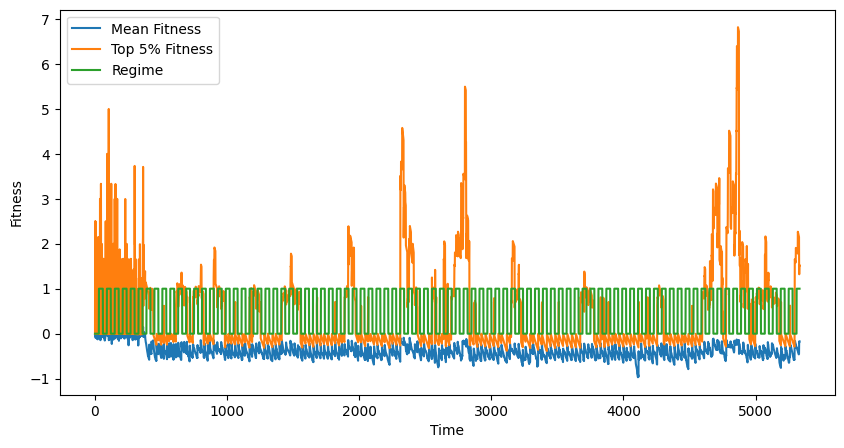

In [2]:
# world.sim_log['t'], world.sim_log['mean_fit'], world.sim_log['top5_fit'], world.sim_log['regime']

import matplotlib.pyplot as plt

#plotting the data
plt.figure(figsize=(10, 5))
plt.plot(world.sim_log['t'], world.sim_log['mean_fit'], label='Mean Fitness')
plt.plot(world.sim_log['t'], world.sim_log['top5_fit'], label='Top 5% Fitness')
plt.plot(world.sim_log['t'], world.sim_log['regime'], label='Regime')
plt.xlabel('Time')
plt.ylabel('Fitness')
plt.legend()
plt.show()